# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [130]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:

import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from loaders import load_items, load_ratings
import analytics as an
importlib.reload(an)
import constants as C
df_items = load_items()
df_items = df_items.reset_index()
df_ratings = load_ratings()





# Descriptive Statistics

In [134]:
an.compute_content_stats(df_items)

Number of films: 8737
Period covered: 1902 - 2016
Genres present: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [135]:
unique_users, unique_movies=an.compute_ratings_stats(df_ratings, df_items,write=True)

Total number of ratings given: 384504
Number of distinct users who rated: 1010
Number of distinct movies that received at least one rating: 8737
Highest number of ratings received by a single movie: 842
Lowest number of ratings received by a movie: 1
All possible rating values used: [0.5, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]
Number of movies that received no rating at all: 0


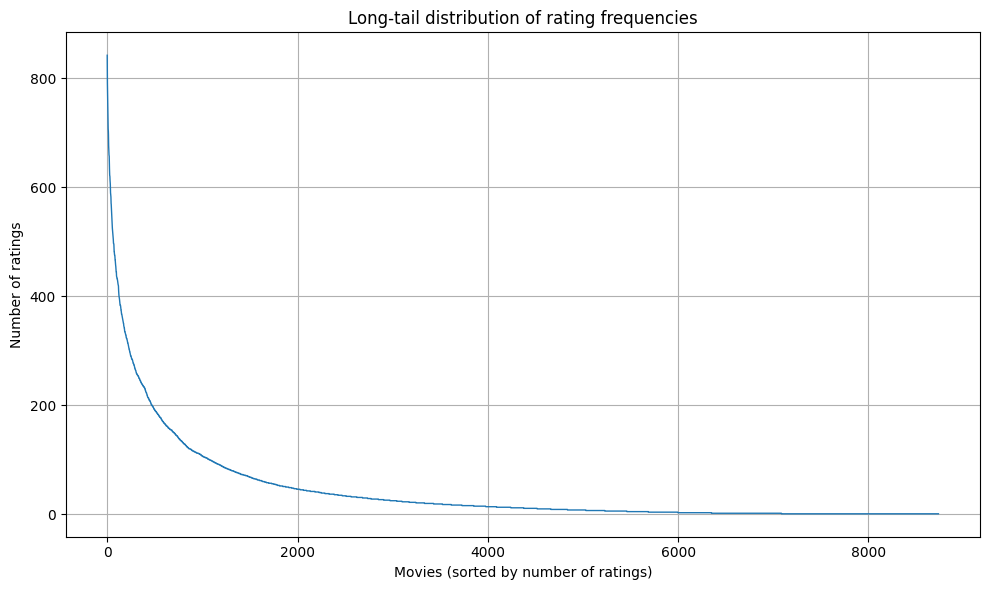

In [116]:


an.plot_long_tail(df_ratings)

In [136]:
unique_users, unique_movies=an.compute_ratings_stats(df_ratings, df_items, write=False)
sparsity = an.compute_sparsity(df_ratings, n_users, n_movies)
print(f"Sparsité de la matrice : {sparsity:.2%}")

Sparsité de la matrice : 95.64%


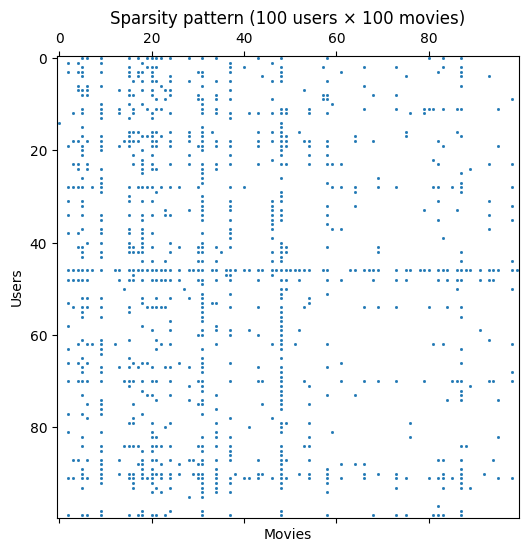

In [137]:
X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = an.create_X(df_ratings)
